In [1]:
print("Hello")

Hello


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
df = pd.read_csv(url)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df.shape

(53940, 10)

In [7]:
print("Dataset Columns: ", df.columns.tolist())
print("Data Types: ", df.dtypes)

Dataset Columns:  ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']
Data Types:  carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object


In [9]:
# Average price of diamonds by cut
avg_price_by_cut = df.groupby('cut')['price'].mean().sort_values(ascending=False)
print(avg_price_by_cut)

cut
Premium      4584.257704
Fair         4358.757764
Very Good    3981.759891
Good         3928.864452
Ideal        3457.541970
Name: price, dtype: float64


In [10]:
# Average price of diamonds by clarity
avg_price_by_clarity = df.groupby('clarity')['price'].mean().sort_values(ascending=False)
print(avg_price_by_clarity)

clarity
SI2     5063.028606
SI1     3996.001148
VS2     3924.989395
I1      3924.168691
VS1     3839.455391
VVS2    3283.737071
IF      2864.839106
VVS1    2523.114637
Name: price, dtype: float64


In [11]:
# Average price of diamonds by color
avg_price_by_color = df.groupby('color')['price'].mean().sort_values(ascending=False)
print(avg_price_by_color)


color
J    5323.818020
I    5091.874954
H    4486.669196
G    3999.135671
F    3724.886397
D    3169.954096
E    3076.752475
Name: price, dtype: float64


In [12]:
print("Missing Values: ", df.isnull().sum())

Missing Values:  carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [13]:
duplicates = df.duplicated().sum()
print("Duplicate Rows: ", duplicates)

Duplicate Rows:  146


In [14]:
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape: ", df.shape)

Duplicates removed. New shape:  (53794, 10)


In [15]:
# Check if any dimension (x, y, z) has zero or negative values
invalid_dimension_mask = (df['x'] <= 0) | (df['y'] <= 0) | (df['z'] <= 0)
print("Invalid dimensions: ", invalid_dimension_mask.sum())

Invalid dimensions:  19


In [16]:
if invalid_dimension_mask.sum() > 0:
    df = df[~invalid_dimension_mask]
    print("Invalid dimensions removed. New shape: ", df.shape)

Invalid dimensions removed. New shape:  (53775, 10)


In [18]:
# Convert categorical columns to categorical numeric datatypes
cut_order = ['Ideal', 'Good', 'Very Good', 'Fair', 'Premium']
df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True)
clarity_order = ['VVS1', 'IF', 'VVS2', 'VS1', 'I1', 'VS2', 'SI1', 'SI2']
df['clarity'] = pd.Categorical(df['clarity'], categories=clarity_order, ordered=True)
color_order = ['E', 'D', 'F', 'G', 'H', 'I', 'J']
df['color'] = pd.Categorical(df['color'], categories=color_order, ordered=True)
print("Data Types after conversion: ", df.dtypes)

Data Types after conversion:  carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object


In [19]:
df_before_trim = df.copy()
depth_low, depth_high = np.percentile(df['depth'], [1, 99])
table_low, table_high = np.percentile(df['table'], [1, 99])

trim_mask = (df['depth'] >= depth_low) & (df['depth'] <= depth_high) & (df['table'] >= table_low) & (df['table'] <= table_high)
df = df[trim_mask]
print("Data shape after trimming: ", df.shape)

Data shape after trimming:  (52458, 10)


In [20]:
df['volume'] = df['x'] * df['y'] * df['z']
df['cut_score'] = df['cut'].cat.codes + 1 # Turning to 1 based indexing
df['clarity_score'] = df['clarity'].cat.codes + 1 # Turning to 1 based indexing
df['color_score'] = df['color'].cat.codes + 1 # Turning to 1 based indexing

In [21]:
corr_mattrix = df.corr(numeric_only=True)
print(corr_mattrix)
print(corr_mattrix['price'].sort_values(ascending=False))

                  carat     depth     table     price         x         y  \
carat          1.000000  0.014454  0.188851  0.924827  0.978833  0.954465   
depth          0.014454  1.000000 -0.278192 -0.015045 -0.030533 -0.033762   
table          0.188851 -0.278192  1.000000  0.136551  0.197753  0.187198   
price          0.924827 -0.015045  0.136551  1.000000  0.889434  0.869038   
x              0.978833 -0.030533  0.197753  0.889434  1.000000  0.974372   
y              0.954465 -0.033762  0.187198  0.869038  0.974372  1.000000   
z              0.961489  0.073952  0.162453  0.871313  0.976895  0.957765   
volume         0.977665 -0.002585  0.174234  0.906101  0.958470  0.977621   
cut_score      0.162616 -0.130626  0.532629  0.113082  0.167973  0.150854   
clarity_score  0.320746  0.048695  0.149912  0.146072  0.343342  0.331294   
color_score    0.288787  0.043899  0.025220  0.174134  0.268993  0.261926   

                      z    volume  cut_score  clarity_score  color_score  


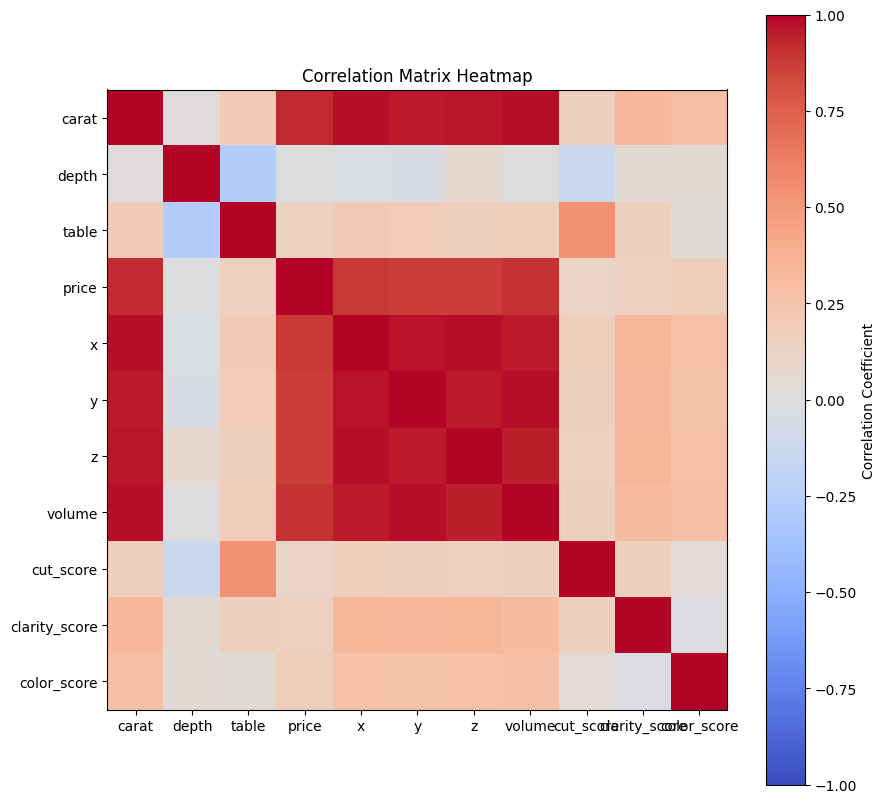

In [22]:
plt.figure(figsize=(10, 10))
plt.imshow(corr_mattrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(corr_mattrix)), corr_mattrix.columns, rotation=0)
plt.yticks(range(len(corr_mattrix)), corr_mattrix.columns)
plt.title('Correlation Matrix Heatmap')
plt.show()

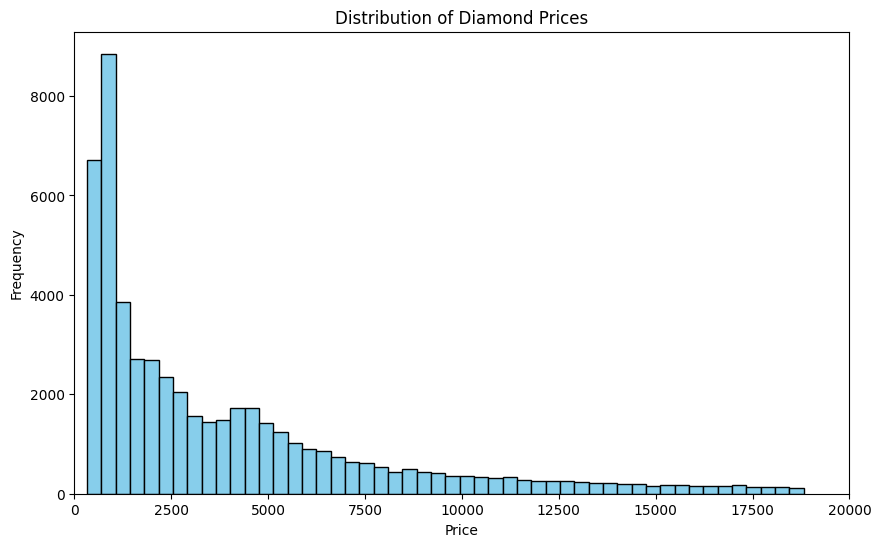

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Diamond Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xlim(0, 20000) # Limiting x-axis for better visualization
plt.show()